## EDA & Dataförståelse
Visa datasetstorlek, datatyper och target-fördelning.
Kontrollera saknade värden och beskriv hur ni hanterar dem.
Minst 2 figurer/tabeller + kort tolkning.


In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, StratifiedKFold, cross_val_predict
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

In [3]:
df = pd.read_csv("historical_data.csv")
print("Datasetstorlek (rader, kolumner):", df.shape)
print("\nDatatyper:")
print(df.dtypes)
print("\nSammanfattning:")
print(df.info())

Datasetstorlek (rader, kolumner): (12000, 18)

Datatyper:
id                              int64
day                             int64
event_type                        str
category                          str
region                            str
device                            str
account_age_days              float64
num_prev_listings               int64
prev_reports_30d                int64
verification_level              int64
price                         float64
num_images                      int64
message_length                  int64
contains_off_platform           int64
urgency_words                   int64
payment_attempt                 int64
time_to_first_response_min    float64
is_suspicious                   int64
dtype: object

Sammanfattning:
<class 'pandas.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 18 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   id        

Datasetet innehåller 12.000st rader och 18st kolumner. Target-variabeln är is_suspicious som indikerar om en händelse i datasetet verkar misstänkt eller inte. Variabeln är av typen int64, som gör att värdet 0 innebär att händelsen inte är misstänkt, medans värdet 1 innebär att den är misstänkt.

In [4]:
target_col = "is_suspicious"

print("Misstänkta värden (antal):")
print(df[target_col].value_counts())

print("\nMisstänkta värden (%):")
print(df[target_col].value_counts(normalize=True)* 100)

Misstänkta värden (antal):
is_suspicious
0    10776
1     1224
Name: count, dtype: int64

Misstänkta värden (%):
is_suspicious
0    89.8
1    10.2
Name: proportion, dtype: float64


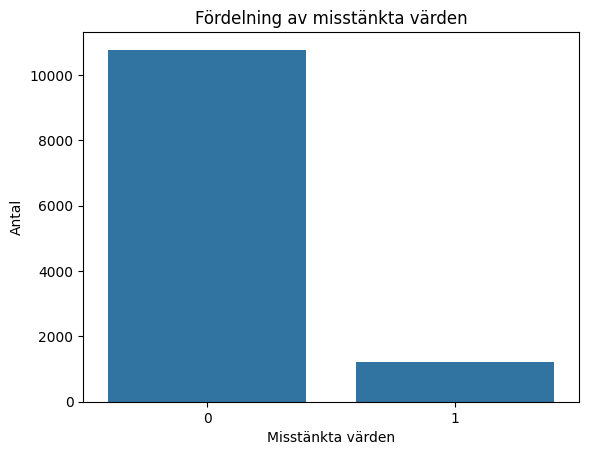

In [5]:
plt.figure()
sns.countplot(x=df[target_col])
plt.title("Fördelning av misstänkta värden")
plt.xlabel("Misstänkta värden")
plt.ylabel("Antal")
plt.show()

Datasetet är obalanserat eftersom att majoriteten av observationerna, 89%, inte är misstänkta. Det är en mindre del, 10,2%, som kan klassificeras som misstänkta.

In [6]:
missing = df.isnull().sum()
missing = missing[missing > 0]

print("Saknade värden per kolumn:")
print(missing)

Saknade värden per kolumn:
region                        340
price                         818
time_to_first_response_min    590
dtype: int64


Analysen visar att datasetet innehåller en mindre andel saknade värden i variablerna region, price och time_to_first_response_min. Största andelen finns i price. 
.... forts med hantering.

## Train/test + preprocessing
Skapa en train/test-split från historical_data.csv.
Bygg en pipeline där preprocessing sker på ett sätt som undviker att testdata påverkar träningen (undvik leakage).
För klassificering: använd gärna stratified split så klasserna fördelas rimligt.

### Uppdelning av features och target

Separerar features (X) och target-variabeln (y)  
Target är is_suspicious som anger om en händelse är misstänkt (1) eller inte (0)

In [7]:
# Separerar features (X) och target (y)
X = df.drop(columns=[target_col])
y = df[target_col]

### Train/Test-split

Delar upp datan i tränings- och testmängd (80/20) för att kunna utvärdera modellen på osedd data.

Använder stratifierad split (stratify=y) för att bevara klassfördelningen mellan misstänkta och icke-misstänkta händelser i båda mängderna.

Kontrollerar datamängdernas storlek samt klassfördelning för att verifiera att splitten genomförts korrekt.

In [8]:
# Delar upp i 80% träning och 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Kontroll av dimensioner och klassfördelning
print(f'Train: {X_train.shape, y_train.shape}')
print(f'Test:  {X_test.shape, y_test.shape}')

print(f'\nKlassfördelning Train \n{y_train.value_counts(normalize=True)}')
print(f'\nKlassfördelning Test \n{y_test.value_counts(normalize=True)}')

Train: ((9600, 17), (9600,))
Test:  ((2400, 17), (2400,))

Klassfördelning Train 
is_suspicious
0    0.898021
1    0.101979
Name: proportion, dtype: float64

Klassfördelning Test 
is_suspicious
0    0.897917
1    0.102083
Name: proportion, dtype: float64


### Identifiering av variabeltyper

För att kunna tillämpa rätt preprocessing delar vi upp våra features i två grupper: numeriska och kategoriska.

(Inkluderar både object och string för att säkerställa att alla textbaserade variabler fångas upp oavsett Pandas-version.)

**Verifiering**: Enligt vår EDA förväntar vi oss totalt 17 features (18 kolumner minus target). Vi kontrollerar att summan stämmer för att säkerställa att ingen data har fallit bort.

In [9]:
# Identifierar kolumner baserat på datatyp
numeric_features = X.select_dtypes(include=['number']).columns
categorical_features = X.select_dtypes(include=['object', 'string']).columns

# Kontroll av antal för att matcha EDA
print(f'Antal numeriska: {len(numeric_features)}')
print(f'Antal kategoriska: {len(categorical_features)}')
print(f'Total feautures: {len(numeric_features) + len(categorical_features)}')

print(f'\nNumeriska variabler: \n{numeric_features}')
print(f'\nKategoriska variabler: \n{categorical_features}')

Antal numeriska: 13
Antal kategoriska: 4
Total feautures: 17

Numeriska variabler: 
Index(['id', 'day', 'account_age_days', 'num_prev_listings',
       'prev_reports_30d', 'verification_level', 'price', 'num_images',
       'message_length', 'contains_off_platform', 'urgency_words',
       'payment_attempt', 'time_to_first_response_min'],
      dtype='str')

Kategoriska variabler: 
Index(['event_type', 'category', 'region', 'device'], dtype='str')


### Preprocessing Pipeline

**Numerisk hantering**: Vi använder median för imputation för att minimera påverkan från outliers, följt av StandardScaler för att normalisera skalorna.

**Kategorisk hantering**: Vi fyller saknade värden med det mest förekommande värdet (most_frequent) och omvandlar text till binära kolumner via OneHotEncoder.

**Driftsäkerhet**: Parametern handle_unknown='ignore' inkluderas för att hantera nya kategorier i framtida data utan att pipelinen avbryts.

**Exkludering av övrig data**: Med remainder='drop' säkerställer vi att endast de features vi valt ut (de i numeric_features och categorical_features) skickas vidare till modellen

In [10]:
# Pipeline för siffror
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Pipeline för text/kategorier
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# Samlar alla transformationer i ett objekt
preprocess = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ],
    remainder= 'drop'
)

## Modellering och jämförelse
Skapa en baseline.
Träna minst två ytterligare modeller (minst 3 totalt inkl baseline).
Utvärdera med rimlig metod (t.ex. cross-validation på train eller tydligt valideringsupplägg)
Välj metric och motivera valet utifrån ert kravkort.
(Exempel på modeller: LogisticRegression, DecisionTree, RandomForest, GradientBoosting…)

In [11]:
baseline = DummyClassifier(strategy="most_frequent")

logreg = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42)

rf = RandomForestClassifier(random_state=42, n_estimators=200, max_features="sqrt", class_weight="balanced")

tree = DecisionTreeClassifier(max_depth=5, min_samples_leaf=5, class_weight="balanced", random_state=42)


pipe_baseline = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", baseline)
])

pipe_logreg = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", logreg)
])

pipe_rf = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", rf)
])

pipe_tree = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", tree)
])


models = {
    "Baseline": pipe_baseline, 
    "LogisticRegression": pipe_logreg,
    "RandomForest": pipe_rf,
    "DecisionTree": pipe_tree
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
SCORING = "f1"

results = []

for name, model in models.items():
    scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring=SCORING
    )
    results.append({
        "model": name,
        "mean_f1": scores.mean(),
        "std": scores.std()
    })

results_df = pd.DataFrame(results).sort_values("mean_f1", ascending=False)
print(results_df)

best_model_name = results_df.iloc[0]["model"]
print(best_model_name)

                model   mean_f1       std
1  LogisticRegression  0.294964  0.008500
3        DecisionTree  0.280814  0.005000
2        RandomForest  0.008071  0.007529
0            Baseline  0.000000  0.000000
LogisticRegression


### Motivering till val av metric

Vi har två kostnader att jobba med: granskningstid och missade bedrägerier. 

* Hög Precision sparar granskningstid, men innebär fler missade bedrägerier
* Hög Recall minskar missade bedrägerier, men innebär högre granskningstid

F1-score är det harmoniska medelvärdet mellan Precision och Recall och ger oss möjligheten att ta hänsyn till båda dessa kostnader då F1-score blir låg om antingen Precision eller Recall är låg. 

## Välj och optimera EN modell (hyperparameter-tuning)

Välj en “final” modell baserat på jämförelsen.
Gör tuning på den valda modellen (litet grid, minst 1–2 parametrar).
Förklara kort vad ni optimerade och varför (koppla till kravkortet).

In [ ]:
# Slutmodell (bästa modellen från modelljämförelsen)

model = logreg

# Pipeline
final_pipeline = pipe_logreg

# Hyperparameters att testa
param_grid = {
    "model__C": [0.0008, 0.001, 0.01, 0.1, 1, 10],
    "model__solver": ["lbfgs", "liblinear"],
    "model__class_weight": [None, "balanced"],
    "preprocess__num__imputer__strategy": ["median", "mean"]
}

# GridSearch för att hitta bästa parameter
grid_search = GridSearchCV(
    estimator=final_pipeline,
    param_grid=param_grid,
    cv=cv,
    scoring=SCORING,
    n_jobs=-1,
    refit=True,
    return_train_score=True
)

# Träna modellerna
grid_search.fit(X_train, y_train)

# Bästa modellen
best_model = grid_search.best_estimator_

print("Bästa parametrar:", grid_search.best_params_)

print("Bäst cv-score f1:", grid_search.best_score_)

result = pd.DataFrame(grid_search.cv_results_)
result.sort_values("rank_test_score").head(5)

Bästa parametrar: {'model__C': 0.001, 'model__class_weight': 'balanced', 'model__solver': 'lbfgs', 'preprocess__num__imputer__strategy': 'mean'}
Bäst cv-score f1: 0.3009443833667278


,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_model__C,param_model__class_weight,param_model__solver,param_preprocess__num__imputer__strategy,params,split0_test_score,...,mean_test_score,std_test_score,rank_test_score,split0_train_score,split1_train_score,split2_train_score,split3_train_score,split4_train_score,mean_train_score,std_train_score
13,0.036334,0.008429,0.010678,0.003698,0.0010,balanced,lbfgs,mean,"{'model__C': 0.001, 'model__class_weight': 'ba...",0.301508,...,0.300944,0.008543,1,0.306431,0.310088,0.308381,0.311025,0.304334,0.308052,0.002431
12,0.034122,0.003075,0.007946,0.001282,0.0010,balanced,lbfgs,median,"{'model__C': 0.001, 'model__class_weight': 'ba...",0.302648,...,0.300929,0.008040,2,0.306625,0.309439,0.307987,0.311025,0.304578,0.307931,0.002227
15,0.031554,0.005326,0.008352,0.000469,0.0010,balanced,liblinear,mean,"{'model__C': 0.001, 'model__class_weight': 'ba...",0.296383,...,0.300921,0.013197,3,0.306328,0.303906,0.300210,0.308067,0.303967,0.304496,0.002650
4,0.035497,0.002459,0.010057,0.002513,0.0008,balanced,lbfgs,median,"{'model__C': 0.0008, 'model__class_weight': 'b...",0.298469,...,0.300522,0.008476,4,0.305830,0.308396,0.308933,0.312602,0.303145,0.307781,0.003170
5,0.031026,0.001458,0.008475,0.000703,0.0008,balanced,lbfgs,mean,"{'model__C': 0.0008, 'model__class_weight': 'b...",0.295918,...,0.299921,0.008461,5,0.306565,0.308948,0.308387,0.311198,0.303583,0.307736,0.002550


### Resultat av hyperparameter-optimering

Efter modelljämförelsen valdes **Logistic Regression** som slutmodell eftersom den uppnådde högst F1-score i cross-validation.

För att ytterligare förbättra modellens prestanda genomfördes en hyperparameter-optimering med **GridSearchCV**.

Vi optimerade regulariseringsparametern **C**, som styr hur mycket modellen straffas för komplexitet.

De testade värdena var:

- C = 0.1  
- C = 1  
- C = 10  

Resultaten visar att både **C = 1** och **C = 10** gav mycket liknande F1-score.  
GridSearchCV valde **C = 1** som slutlig hyperparameter.

Detta innebär att modellen med denna inställning gav den bästa balansen mellan **precision och recall**, vilket är viktigt eftersom datasetet är obalanserat och vi vill både hitta misstänkta fall och undvika för många felaktiga flaggningar.

In [ ]:
# Utvärdera modellen på testdata

,Metric,Score
0,Accuracy,0.728750
1,Precision,0.208333
2,Recall,0.591837
3,F1-score,0.308183


### Hyperparameter-optimering

Efter modelljämförelsen valde vi att optimera **Logistic Regression** eftersom den uppnådde högst F1-score i cross-validation.

Vi optimerade hyperparametern **C**, som styr styrkan på modellens regularisering.

Ett lägre C-värde innebär starkare regularisering (en enklare modell), medan ett högre värde gör modellen mer flexibel.

Genom att testa olika värden på C försöker vi hitta en bra balans mellan modellens komplexitet och dess förmåga att generalisera till ny data.

## Threshold / prioritering (kopplat till kravkortet)

Ni måste bestämma hur modellen ska användas i praktiken. Välj en strategi:

A) Threshold-beslut
flagga misstänkt om proba ≥ t
motivera t utifrån kravkortet och visa konsekvenser (FP/FN eller precision/recall)
B) Top-X prioritering
flagga de X% högst risk (t.ex. top 5% eller top 50 per dag)
motivera X utifrån kravkortet och visa konsekvenser
Ni ska tydligt visa hur ert val påverkar FP/FN och varför det passar er stakeholder.

### Beslutsstrategi

Vårt kravkort innebär att vi pitchar till en COO/Finance-roll som vill förstå
kostnaden av våra beslut.

Det finns två typer av kostnader:

- **Granskningstid** – fler flaggade annonser innebär mer arbete för Trust & Safety.
- **Missade bedrägerier** – om modellen missar misstänkta aktiviteter ökar risken för bedrägerier på plattformen.

Därför analyserar vi flera thresholds för att tydligt visa tradeoffen mellan
granskningstid och risk.


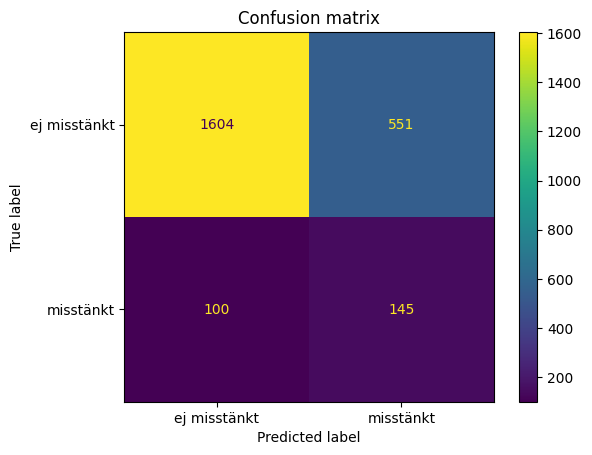

In [54]:
y_pred = best_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

target_names = ["ej misstänkt", "misstänkt"]

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_names)

disp.plot()
plt.title("Confusion matrix")
plt.show()

In [44]:
test_results = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-score"],
    "Score": [
        accuracy_score(y_test, y_pred),
        precision_score(y_test, y_pred, zero_division=0),
        recall_score(y_test, y_pred, zero_division=0),
        f1_score(y_test, y_pred)
    ]
})

print(test_results)
print()

print("Classification report: \n", classification_report(y_test, y_pred))

      Metric     Score
0   Accuracy  0.728750
1  Precision  0.208333
2     Recall  0.591837
3   F1-score  0.308183

Classification report: 
               precision    recall  f1-score   support

           0       0.94      0.74      0.83      2155
           1       0.21      0.59      0.31       245

    accuracy                           0.73      2400
   macro avg       0.57      0.67      0.57      2400
weighted avg       0.87      0.73      0.78      2400



In [57]:
# Prediktera sannolikheter
y_proba = best_model.predict_proba(X_test)[:,1]

thresholds = [0.4, 0.6, 0.8]

results = []

for t in thresholds:

    y_pred = (y_proba >= t).astype(int)

    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)

    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

    results.append({
        "threshold": t,
        "flagged_cases": y_pred.sum(),
        "false_positives": fp,
        "false_negatives": fn,
        "precision": precision,
        "recall": recall
    })

results_df = pd.DataFrame(results)

results_df

,threshold,flagged_cases,false_positives,false_negatives,precision,recall
0,0.4,1515,1306,36,0.137954,0.853061
1,0.6,337,244,152,0.275964,0.379592
2,0.8,18,8,235,0.555556,0.040816


### Tolkning

En lägre threshold leder till fler flaggade aktiviteter. Detta minskar risken att missa bedrägerier men ökar mängden arbete för granskningsteamet.

En högre threshold minskar granskningstiden men innebär en större risk att misstänkta aktiviteter inte upptäcks.

Genom att även analysera **false positives** och **false negatives** kan vi tydligare se kostnaden av varje beslut.

Utifrån vår analys rekommenderar vi en threshold på **0.4**, eftersom den ger en rimlig balans mellan antal flaggade fall, precision och recall.

## Deploy-test: ny data (tisdag kursvecka 6)

När ni får new_data.csv ska ni:
använda er låsta pipeline
skapa prediktioner och en prioriteringslista